# A02 — Extended Framework & Structural Ablations
Covers: `fig:appendix-stage-layout` — (a) cue/group-org variants, (b) scope-semantics/layout variants, (c) stage-placement/ordering/router variants  (Appendix D: `app:stage-layout`)


In [6]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import appendix_viz_helpers as viz
importlib.reload(viz)

apply_style    = viz.apply_style
load_csv       = viz.load_csv
annotate_demo  = viz.annotate_demo
clean_axes     = viz.clean_axes
dataset_label  = viz.dataset_label
metric_limits  = viz.metric_limits
palette_for    = viz.palette_for
bar_line_panel = viz.bar_line_panel
panel_label    = viz.panel_label
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()


In [7]:
structural = load_csv('appendix_structural_variants.csv')
structural['dataset_label'] = structural['dataset'].map(dataset_label)
print(f"structural: {structural.shape}  columns: {structural.columns.tolist()}")
print("variant_labels:", structural['variant_label'].unique() if 'variant_label' in structural.columns else 'N/A')


structural: (44, 11)  columns: ['dataset', 'variant_label', 'variant_group', 'variant_order', 'test_ndcg20', 'test_hit10', 'base_rank', 'seed_id', 'data_status', 'data_note', 'dataset_label']
variant_labels: ['Final 3-stage' 'Single-view (macro only)' 'Two-view (macro+mid)'
 'Local-first ordering' 'Global-late ordering' 'Duplicated mid stage'
 'Family Prior Intact' 'Fewer Semantic Groups' 'Groups Shuffled'
 'Flat Scalar Bag' 'Random Group Assignment']


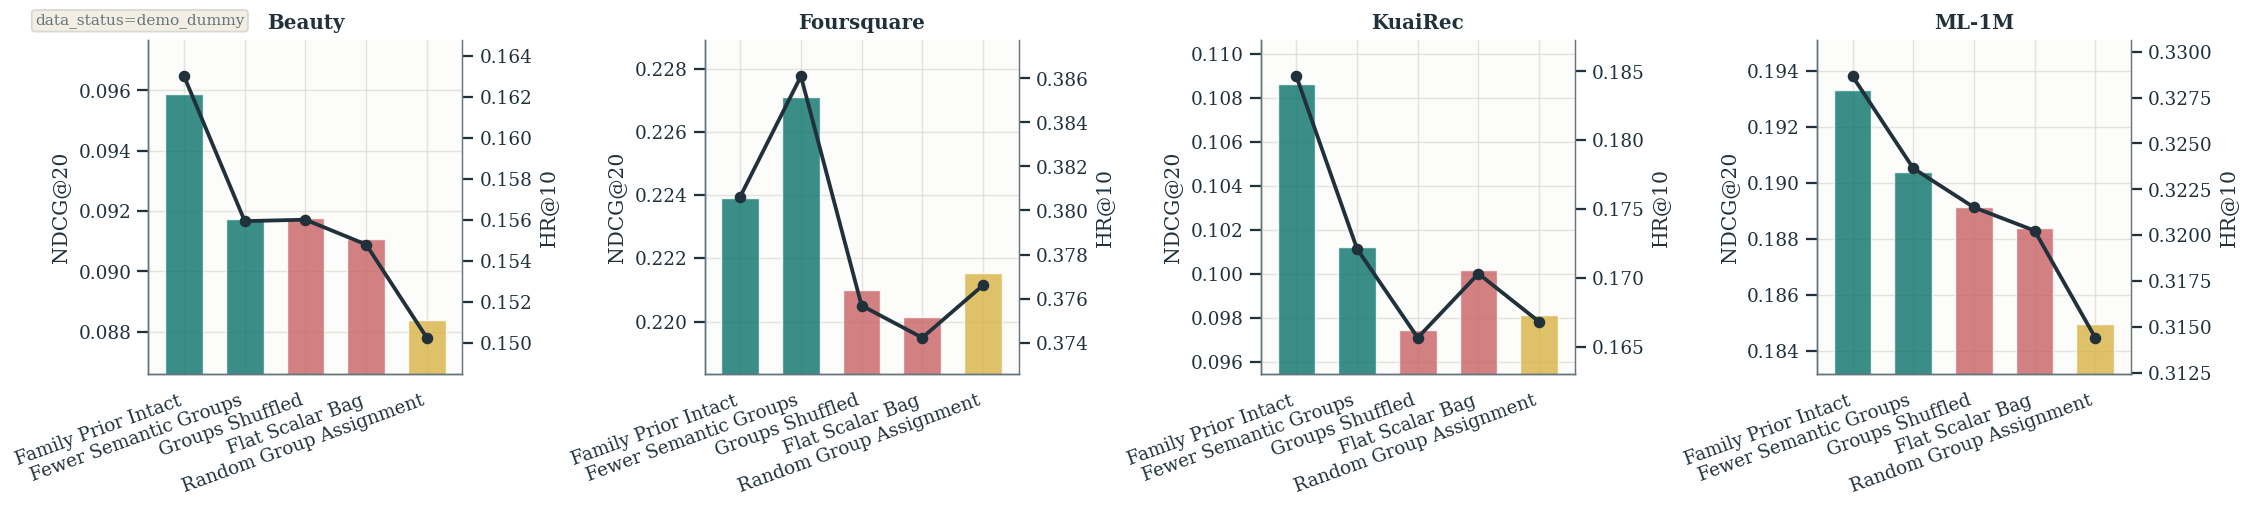

In [ ]:

# ── (a) Cue / group-organisation variants — averaged across datasets ─────────────────────
# One compact bar_line_panel; short labels; suitable for 0.48\textwidth in figure*
CUEORG_SHORT = {
    'Family Prior Intact':     'Family\n(main)',
    'Fewer Semantic Groups':   'Fewer\nGroups',
    'Groups Shuffled':         'Shuffled',
    'Flat Scalar Bag':         'Flat\nBag',
    'Random Group Assignment': 'Random',
}
sub_a = structural[structural['variant_group'] == 'cue_org'].copy()
sub_a['variant_short'] = sub_a['variant_label'].map(CUEORG_SHORT).fillna(sub_a['variant_label'])

# Determine order from variant_order column
order_meta = (sub_a[['variant_label', 'variant_short', 'variant_order']]
              .drop_duplicates()
              .sort_values('variant_order'))
short_order_a = order_meta['variant_short'].tolist()

# Average across datasets
avg_a = (sub_a.groupby('variant_short', as_index=False)[['test_ndcg20', 'test_hit10']].mean())
avg_a['variant_short'] = pd.Categorical(avg_a['variant_short'],
                                         categories=short_order_a, ordered=True)
avg_a = avg_a.sort_values('variant_short')

fig_a, ax_a = plt.subplots(figsize=(5.5, 3.5), constrained_layout=True)
bar_line_panel(avg_a, category_col='variant_short',
               bar_col='test_ndcg20', line_col='test_hit10',
               ax=ax_a, order=short_order_a,
               bar_label='NDCG@20', line_label='HR@10',
               xrotation=0)
annotate_demo(fig_a, sub_a)
fig_a.savefig('data/fig_D_cue_org_variants.pdf', bbox_inches='tight')
plt.show()
print("Saved: data/fig_D_cue_org_variants.pdf")


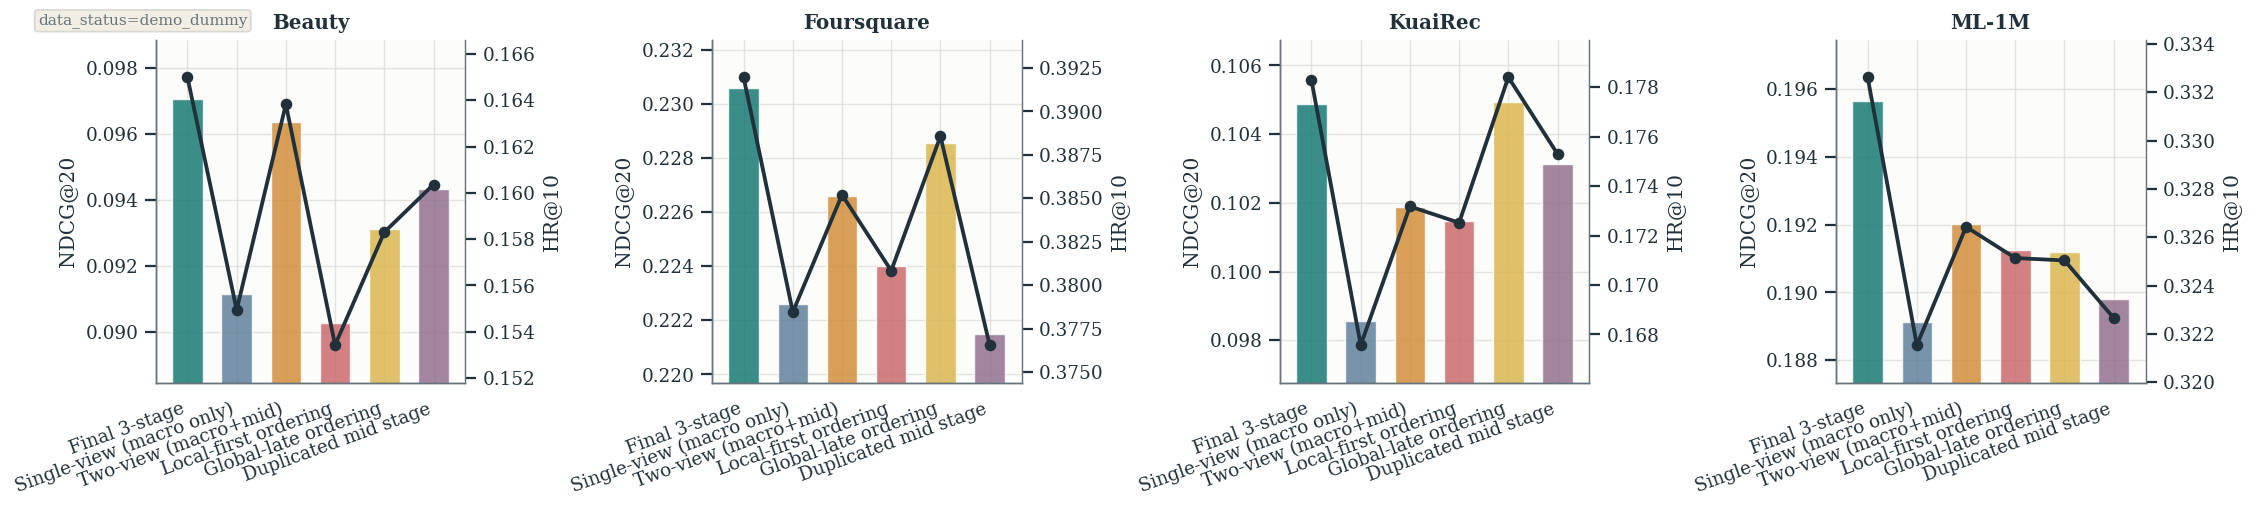

In [ ]:

# ── (b) Temporal / stage-layout variants — averaged across datasets ──────────────────────
# One compact bar_line_panel; short labels; suitable for 0.48\textwidth in figure*
TEMPORAL_SHORT = {
    'Final 3-stage':           '3-stage\n(main)',
    'Single-view (macro only)': 'Macro\nOnly',
    'Two-view (macro+mid)':    'Macro\n+Mid',
    'Local-first ordering':    'Local\nFirst',
    'Global-late ordering':    'Global\nLate',
    'Duplicated mid stage':    'Dup.\nMid',
}
sub_b = structural[structural['variant_group'] == 'temporal'].copy()
sub_b['variant_short'] = sub_b['variant_label'].map(TEMPORAL_SHORT).fillna(sub_b['variant_label'])

order_meta_b = (sub_b[['variant_label', 'variant_short', 'variant_order']]
                .drop_duplicates()
                .sort_values('variant_order'))
short_order_b = order_meta_b['variant_short'].tolist()

# Average across datasets
avg_b = (sub_b.groupby('variant_short', as_index=False)[['test_ndcg20', 'test_hit10']].mean())
avg_b['variant_short'] = pd.Categorical(avg_b['variant_short'],
                                         categories=short_order_b, ordered=True)
avg_b = avg_b.sort_values('variant_short')

fig_b, ax_b = plt.subplots(figsize=(5.5, 3.5), constrained_layout=True)
bar_line_panel(avg_b, category_col='variant_short',
               bar_col='test_ndcg20', line_col='test_hit10',
               ax=ax_b, order=short_order_b,
               bar_label='NDCG@20', line_label='HR@10',
               xrotation=0)
annotate_demo(fig_b, sub_b)
fig_b.savefig('data/fig_D_temporal_variants.pdf', bbox_inches='tight')
plt.show()
print("Saved: data/fig_D_temporal_variants.pdf")
